In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.data.datasets import QM9

ds = QM9(include_pos=True, include_charges=True)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/data/dataset.py:240: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{wa

In [3]:
ds.mol_to_torch_converter.bond_decoder

{0: 'DOUBLE', 1: 'TRIPLE', 2: 'SINGLE'}

In [3]:
GDB13_RAW_SMI = 'gdb13.rand1M.smi'
import os.path as osp
from src.data.datasets.core import DEFAULT_DATASET_PATH


DEFAULT_DATASET_PATH_GDB13 = osp.join(DEFAULT_DATASET_PATH, 'gdb13')
GDB13_RAW_SMI = 'gdb13.rand1M.smi'
GDB13_DATA_URL = 'https://zenodo.org/record/5172018/files/gdb13.rand1M.smi.gz?download=1&ref=gdb.unibe.ch'

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::__1::vector<int, std::__1::allocator<int>> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::__1::vector<double, std::__1::allocator<double>> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::__1::vector<std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>>, std::__1::allocator<std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>>>> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::__1::vector<std::__1::vector<double, std::__1::allocator<double>>, std::__1::allocator<std::__1::vector<double, std::__1::allocator<double>>>> already registered; second conversion method ignored.
<frozen importlib._boots

In [4]:
from torch_geometric.data import extract_zip, download_url, extract_gz
gz_file = download_url(GDB13_DATA_URL, DEFAULT_DATASET_PATH_GDB13)
extract_gz(gz_file, DEFAULT_DATASET_PATH_GDB13)

Using existing file gdb13.rand1M.smi.gz
Extracting datasets/gdb13/gdb13.rand1M.smi.gz


In [5]:
smiles_file = osp.join(DEFAULT_DATASET_PATH_GDB13, GDB13_RAW_SMI)

In [6]:
import src.data.utils.molecular as molutils
smiles = molutils.read_molecules(smiles_file)

In [217]:
from src.data.datasets.gdb13 import GDB13Raw

ds_raw = GDB13Raw(subset_size=169550)

Extracting datasets/gdb13/raw/gdb13.rand1M.smi.gz
Processing molecules: 100%|██████████| 999999/999999 [00:43<00:00, 23059.00it/s, Skipped: 0 (sanit. failed)]


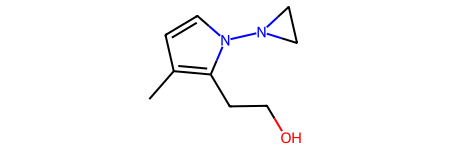

In [232]:
ds_raw[0]

In [6]:
from src.data.datasets import QM9Raw

ds = QM9Raw()

In [2]:
from src.data.datasets.gdb13 import GDB13Resources
from src.data.transforms import ToOneHotAdapter
from src.data.filters.molecular import FilterQuickInvalidPosMol

data_resources = GDB13Resources(
    random_splits={
        'train': None,
        'valid': 10000,
        'test': 10000
    },
    pre_transform=ToOneHotAdapter({
        'num_classes_node': 'num_cls_nodes',
        'num_classes_edge': 'num_cls_edges'
    }),
    include_pos=True,
    include_charges=True,
    pre_filter_raw=FilterQuickInvalidPosMol(),
    subset_size=169550,
    num_workers=10
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: ToOneHotAdapter.__init__() missing 1 required positional argument: 'map'

In [1]:
from src.data.datasets.qm9 import QM9Resources
from src.data.transforms import ToOneHotAdapter, ToOneHotGraphAdapter

data_resources = QM9Resources(
    random_splits={
        'train': None,
        'valid': 10000,
        'test': 10000
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    include_pos=True,
    include_charges=True
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_resources.prepare_data()

Extracting datasets/qm9/raw/qm9.zip
Processing molecules: 100%|██████████| 133885/133885 [00:15<00:00, 8643.93it/s, Skipped: 3054 (skip list), 637 (sanit. failed)] 
Processing...
Done!
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
Converting Chem.Mols to SMILES strings: 100%|██████████| 130194/130194 [00:04<00:00, 27166.79it/s]


Creating random splits for QM9 graphs and SMILES
Applying preprocessing to the whole dataset


In [5]:
ds_train = data_resources.get('dataset', 'train')
ds_val = data_resources.get('dataset', 'valid')
ds_test = data_resources.get('dataset', 'test')

In [14]:
ds_train[1].node_charges

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]])

In [ ]:
# get images of molecules

from rdkit.Chem import Draw

img = Draw.MolsToGridImage([ds_train.mol_to_torch_converter(ds_train[i]) for i in range(16)], molsPerRow=4, subImgSize=(200, 200))

In [ ]:
# get images of 3D molecules
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Draw

mols_3d = []
for i in range(16):
    mol = ds_train.mol_to_torch_converter(ds_train[i])
    mol = AllChem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.UFFOptimizeMolecule(mol)
    mols_3d.append(mol)
    
img_3d = Draw.MolsToGridImage(mols_3d, molsPerRow=4, subImgSize=(200, 200))
img_3d

AttributeError: module 'rdkit.Chem.AllChem' has no attribute 'calcImplicitValence'

In [6]:
from src.data.dataloader import DataLoader
dl = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=10)

In [7]:
batch = next(iter(dl))

In [8]:
from src.datatypes.dense import sparse_graph_to_dense_graph
import torch

dense_batch = sparse_graph_to_dense_graph(batch, handle_one_hot=True)
dense_batch.edge_dist = torch.cdist(dense_batch.node_pos, dense_batch.node_pos)
dense_batch = dense_batch.apply_mask()

num_cls_x = dense_batch.x.shape[-1]
num_cls_e = dense_batch.edge_adjmat.shape[-1]
num_cls_c = dense_batch.node_charges.shape[-1]

In [15]:
config = {
    'x': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'edge_adjmat': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'edge_dist': {
        'process': {'name': 'vp_gaussian'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'node_charges': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    }
}

process_kwargs = {
    'x': {'num_cls': num_cls_x},
    'edge_adjmat': {'num_cls': num_cls_e},
    'node_charges': {'num_cls': num_cls_c}
}

# create omega config
from omegaconf import OmegaConf
config = OmegaConf.create(config)

In [25]:
cfg = config.edge_adjmat.process

cfg['params'] = {'num_cls': 1}

In [7]:
import os
filepath = '/app/checkpoints/qm9-d4/v3_pp8nyio2/epoch=759-step=81320-EMA.ckpt'
directory = os.path.dirname(filepath)
filename = os.path.basename(filepath)
# get all files in the directory
files = os.listdir(directory)
for f in files:
    if 'EMA' in f and not 'last' in f and f != filename:
        print(f)
        break

epoch=790-step=81331-EMA.ckpt


In [ ]:
from src.noise.core import noise_process_from_config, dict_of_noise_processes_from_config

processes = dict_of_noise_processes_from_config(config, process_kwargs=process_kwargs)

In [10]:
from src.noise.graph_diffusion import GraphDiffusionProcess

diffusion = GraphDiffusionProcess(
    diffusion_procs_per_data=processes,
    undirected=True
)

In [12]:
import torch
time = torch.randint(1, 500, (32,))

noisy_batch = diffusion.sample_from_original(dense_batch, time)

In [ ]:
ds_train[0]

SparseGraph(x=[8, 4], edge_index=[2, 20], edge_attr=[20, 3], node_pos=[8, 3], node_charges=[8, 3], y=[19], collapsed=[1])

In [10]:
ds_train[0].collapse('x', 'edge_attr', 'node_charges')

SparseGraph(x=[8], edge_index=[2, 20], edge_attr=[20], node_pos=[8, 3], node_charges=[8], y=[19], collapsed=True)

In [11]:
ds_train[0].to_onehot({'x': 4, 'edge_attr': 3, 'node_charges': 3})

SparseGraph(x=[8, 4], edge_index=[2, 20], edge_attr=[20, 3], node_pos=[8, 3], node_charges=[8, 3], y=[19], collapsed=[1])

In [37]:
ds_train.pre_transform

Compose([
  ToOneHotGraph(num_classes_node=4, num_classes_edge=3),
  ToOneHot(attr_name=node_charges, num_classes=3)
])

In [5]:
ds_train.edge_attr.argmax(dim=-1).unique(return_counts=True)

(tensor([0, 1, 2]), tensor([1804552,  208494,   61754]))

In [34]:
from src.evaluation.metrics.sampling import BondDistanceDistributionMetric

metric = BondDistanceDistributionMetric(ds_val)

In [35]:
metric.bond_types_probabilities

tensor([0.2376, 0.0275, 0.0084, 0.0000])

In [29]:
from src.evaluation.assignment.molecular import MolecularAssignment

assignment = MolecularAssignment(
    how_many_to_generate=10000,
    split='valid',
    data_resources=data_resources,
    metrics_3d=True
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(

In [30]:
assignment.metrics['bond_distance'].bond_types_probabilities

tensor([0.4752, 0.0551, 0.0168, 0.0000])

In [23]:
def preproc(mol):
    mol = mol.clone()
    mol.x = mol.x.argmax(dim=-1)
    mol.edge_attr = mol.edge_attr.argmax(dim=-1)
    mol.node_charges = mol.node_charges.argmax(dim=-1)
    return mol
gen_mols = [preproc(ds_train[i]) for i in range(10000)]
assignment(gen_mols)

TypeError: unsupported operand type(s) for *: 'Tensor' and 'dict'

In [40]:
import torch
print((torch.tensor([0.009, 0.011, 0.269, 0.0])*torch.tensor([0.2388, 0.0273, 0.0079, 0])).sum())
print((torch.tensor([0.017, 0.027, 0.066, 0.0])*torch.tensor([0.2388, 0.0273, 0.0079, 0])).sum())

tensor(0.0046)
tensor(0.0053)


In [ ]:

metric(gen_mols)

0.00277112


{'bond_distance': tensor(0.0128),
 'bond_distance_per_class': {'single': 0.0008507892489433289,
  'double': 0.3917207717895508,
  'triple': 0.008763935416936874,
  'aromatic': 0.0}}

In [61]:
# compute distance matrices for each training graph
from torch_geometric.utils import to_dense_adj
import torch
def compute_dists_types(data):
    types = to_dense_adj(data.edge_index, edge_attr=data.edge_attr.argmax(-1)+1, max_num_nodes=data.num_nodes)
    dists = torch.cdist(data.node_pos, data.node_pos, p=2)
    triang_matrix = torch.triu(torch.ones_like(dists), diagonal=1).bool()
    dists = dists[triang_matrix]
    types = types[0][triang_matrix]
    
    return (dists, types)

dists_types = [compute_dists_types(data) for data in ds_train]

In [62]:
dists_types[0]

(tensor([1.4097, 2.4201, 3.7873, 4.8459, 5.0322, 6.1959, 4.0188, 2.7637, 1.5248,
         2.5527, 3.8044, 4.2932, 5.5068, 3.6507, 2.3558, 1.5251, 2.4338, 2.8230,
         4.0288, 2.3576, 1.4238, 1.4559, 2.5089, 3.6227, 2.8842, 2.4032, 1.3634,
         2.2706, 2.4496, 2.7399, 1.2158, 1.5285, 2.4826, 2.3939, 3.5911, 1.4163]),
 tensor([3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3, 3, 0, 0,
         0, 0, 3, 0, 0, 0, 1, 3, 0, 0, 0, 3]))

In [63]:
# prepare histograms of distances for each edge type
import numpy as np
import matplotlib.pyplot as plt
all_dists = np.concatenate([dts[0].numpy().flatten() for dts in dists_types])
all_types = np.concatenate([dts[1].numpy().flatten() for dts in dists_types])
num_edge_types = all_types.max()+1

In [64]:
torch.from_numpy(all_types).unique()

tensor([0, 1, 2, 3])

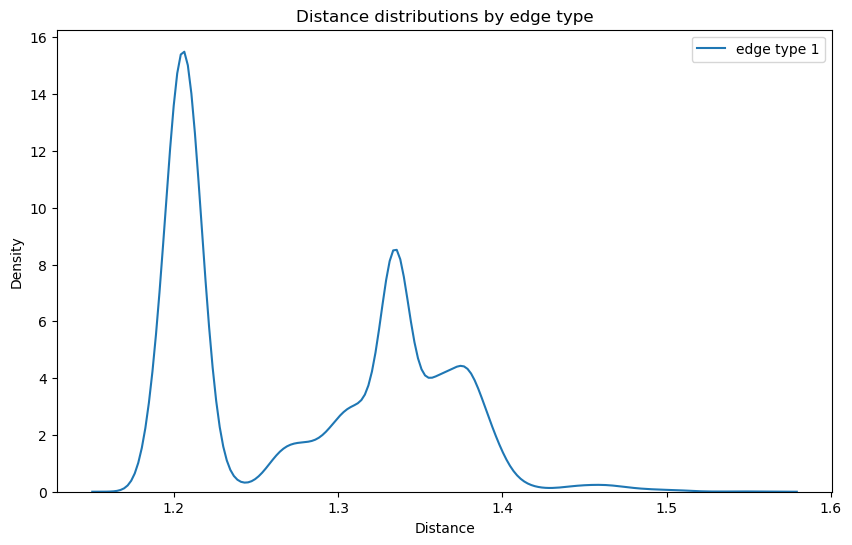

In [68]:
# plot kdes
import seaborn as sns
plt.figure(figsize=(10,6))
show_types = [ds_train.mol_to_torch_converter.bond_encoder['DOUBLE']+1]
for et in show_types:
    sns.kdeplot(all_dists[all_types==et], label=f'edge type {et}', bw_adjust=1.)
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title('Distance distributions by edge type')
plt.legend()
plt.show()